In [1]:
# Importing the libraries
#14065234
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dask.dataframe as dd

In [2]:
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [3]:
# Importing the dataset
dataset = pd.read_csv("/scratch/ope4/MERGE/DEC-04-2024/SENTINEL/damage_points_cropped.csv")

# Drop the 'Unnamed: 0' column from the DataFrame
#dataset = dataset.drop(columns=['Unnamed: 0'])

# Check the columns after dropping
print(dataset.columns)

# Drop multiple columns
dataset.drop(['SURVEY_YEAR', 'geom', 'prec', 'tmax', 'tmin'], axis=1, inplace=True)

#dataset = dataset.query('STATUS != 0')

print(dataset.columns)



Index(['SENTINEL_1', 'SENTINEL_2', 'SENTINEL_3', 'SENTINEL_4', 'SENTINEL_5',
       'SENTINEL_6', 'SENTINEL_7', 'SENTINEL_8', 'SENTINEL_9', 'SENTINEL_10',
       'SENTINEL_11', 'SENTINEL_12', 'SURVEY_YEAR', 'prec', 'tmax', 'tmin',
       'STATUS', 'geom'],
      dtype='object')
Index(['SENTINEL_1', 'SENTINEL_2', 'SENTINEL_3', 'SENTINEL_4', 'SENTINEL_5',
       'SENTINEL_6', 'SENTINEL_7', 'SENTINEL_8', 'SENTINEL_9', 'SENTINEL_10',
       'SENTINEL_11', 'SENTINEL_12', 'STATUS'],
      dtype='object')


In [4]:
# Subset the data for class 0
class_0 = dataset[dataset['STATUS'] == 0]

# Filter the data for rows where STATUS is not 0
dataset = dataset[dataset['STATUS'] != 0]

# Randomly sample 3400 rows from class_0
sample_class_0 = class_0.sample(n=14400, random_state=42)  # Set seed for reproducibility

# View or work with the sampled data
print(sample_class_0.head())

# Combine the sampled rows with the filtered data
dataset = pd.concat([sample_class_0, dataset], ignore_index=True)

        SENTINEL_1  SENTINEL_2  SENTINEL_3  SENTINEL_4  SENTINEL_5  \
46557         2033        1952        2168        1999        2201   
116615         331         371         552         658         961   
151636         331         389         580         667         992   
85244          299         427         581         678         940   
185906         250         391         591         657         966   

        SENTINEL_6  SENTINEL_7  SENTINEL_8  SENTINEL_9  SENTINEL_10  \
46557         3087        3349        3398        3218         3794   
116615        1361        1507        1555        1701         1716   
151636        1463        1662        1682        1851         1886   
85244         1350        1488        1469        1652         1674   
185906        1609        1809        1894        1917         1832   

        SENTINEL_11  SENTINEL_12  STATUS  
46557           696          487       0  
116615         2209         1822       0  
151636         2037    

In [5]:
col_name = 'STATUS'

frequency_table = dataset[col_name].value_counts()

# Display the frequency table
print(frequency_table)

STATUS
1    16876
0    14400
2    10690
Name: count, dtype: int64


In [6]:
#dataset = dataset.query('STATUS != 0')
#print(dataset)

In [6]:
#dataset = dd.read_csv("/scratch/ope4/MERGE/RF.csv")
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
print(X)
print(y)

[[2033 1952 2168 ... 3794  696  487]
 [ 331  371  552 ... 1716 2209 1822]
 [ 331  389  580 ... 1886 2037 1550]
 ...
 [ 272  364  553 ... 1651 1972 1310]
 [ 348  463  666 ... 2061 2651 1988]
 [ 223  222  382 ... 2246 1069  600]]
[0 0 0 ... 2 2 2]


In [7]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3979, random_state = 1)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

# Shuffle the data manually (if needed)
X_train, y_train = np.random.permutation(X_train), np.random.permutation(y_train)
X_test, y_test = np.random.permutation(X_test), np.random.permutation(y_test)

[[ 328  398  655 ... 2565 1636  887]
 [ 156  217  422 ... 2337 1308  684]
 [4974 4751 4376 ... 6076 1816 1521]
 ...
 [ 342  538  770 ... 1857 2055 1512]
 [ 200  277  449 ... 1886 1338  863]
 [2017 1418 1672 ... 3546 1037  765]]
[[5699 6357 6314 ... 8741 3017 2151]
 [ 402  628  840 ... 1977 2494 1992]
 [ 246  299  576 ... 2305 1960 1204]
 ...
 [ 276  296  497 ... 1814 1924 1505]
 [ 335  402  615 ... 2070 1744 1145]
 [ 379  571  789 ... 2110 2113 1716]]
[2 2 1 ... 0 0 2]
[0 1 2 ... 0 2 1]


In [8]:
# Check class distributions for each dataset
print("Class distribution in data:")
print(dataset['STATUS'].value_counts())

# Assuming 'y_train' and 'y_test' are NumPy arrays
print("\nClass distribution in y_train:")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

print("\nClass distribution in y_test:")
unique, counts = np.unique(y_test, return_counts=True)
print(dict(zip(unique, counts)))

Class distribution in data:
STATUS
1    16876
0    14400
2    10690
Name: count, dtype: int64

Class distribution in y_train:
{0: 8659, 1: 10173, 2: 6435}

Class distribution in y_test:
{0: 5741, 1: 6703, 2: 4255}


In [9]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.datasets import make_hastie_10_2

clf = HistGradientBoostingClassifier(max_iter=100).fit(X_train, y_train)
clf.score(X_test, y_test)

0.39415533864303254

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

# Generate predictions with the best model
y_pred = clf.predict(X_test)  # Use test features to predict

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)  # Compare true labels with predictions

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 511 5189   41]
 [ 587 6037   79]
 [ 394 3827   34]]


In [13]:
# If X is a numpy array, convert it back to a DataFrame
feature_names = ['SENTINEL_1', 'SENTINEL_2', 'SENTINEL_3', 'SENTINEL_4', 'SENTINEL_5', 'SENTINEL_6',
                 'SENTINEL_7', 'SENTINEL_8', 'SENTINEL_9','SENTINEL_10', 'SENTINEL_11', 'SENTINEL_12']  # Manually specify feature names

#, 'prec', 'tmax', 'tmin'
X = pd.DataFrame(X, columns=feature_names)

In [14]:
from sklearn.inspection import permutation_importance

# Get permutation importance
perm_importance = permutation_importance(clf, X, y, n_repeats=50, random_state=42)

# Display importance
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Permutation Importance': perm_importance.importances_mean
})

# Sort by importance
perm_importance_df = perm_importance_df.sort_values(by='Permutation Importance', ascending=False)
print(perm_importance_df)


/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  

        Feature  Permutation Importance
0    SENTINEL_1                     0.0
1    SENTINEL_2                     0.0
2    SENTINEL_3                     0.0
3    SENTINEL_4                     0.0
4    SENTINEL_5                     0.0
5    SENTINEL_6                     0.0
6    SENTINEL_7                     0.0
7    SENTINEL_8                     0.0
8    SENTINEL_9                     0.0
9   SENTINEL_10                     0.0
10  SENTINEL_11                     0.0
11  SENTINEL_12                     0.0


/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  

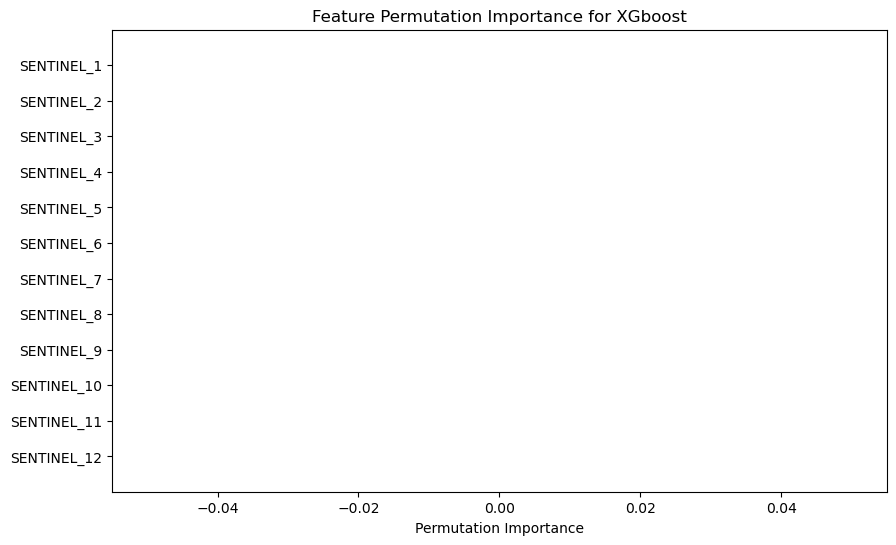

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Create DataFrame
importance_df = pd.DataFrame(perm_importance_df)

# Sort by importance
importance_df = importance_df.sort_values(by='Permutation Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Permutation Importance'], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Feature Permutation Importance for XGboost')
plt.gca().invert_yaxis()  # To have the most important feature at the top
plt.show()